# Práctica 1: Aprendizaje Automático
**Predicción de Subscripsción a un Producto Bancario**

* **Autores:** Jaime del Campo Montaña & David Alexander Torres Paillacho
* **NIA's:** 100495957 100522187

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

# Ignorar warnings para una presentación más limpia
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Definimos una semilla para que los resultados sean reproducibles
RANDOM_STATE = 100522187

# Para asegurar que pandas muestre todas las columnas en el EDA
pd.set_option('display.max_columns', None)


## 2. EDA Simplificado
A continuación realizamos una exploración inicial de los datos para decidir nuestra estrategia de preprocesamiento:
* Comprobaremos la cantidad de valores nulos.
* Analizaremos la cardinalidad de las variables categóricas.
* Estudiaremos la distribución de la variable objetivo (`deposit`).
* Analizaremos variables con valores especiales como `pdays`.

In [3]:
# Carga del dataset original
try:
    df = pd.read_pickle('bank_15.pkl')
    print(f"✅ Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")
except Exception as e:
    print(f"❌ Error al cargar: {e}")

# Vista previa
df.head()

✅ Dataset cargado: 11000 filas y 17 columnas.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


A continuación analizaremos los datos del dataset


### 2.1 Tamaño del dataset y tipos de variables
Vamos a comprobar cuántas filas (instancias) y columnas (variables) tiene nuestro conjunto de datos. Después, separaremos las columnas en numéricas y categóricas para saber con qué estamos trabajando.

In [4]:
#dimensiones del dataset
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.\n")

#resumen de nulos y tipos de datos 
resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos (NaN)': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})

#identificar 'unknown'
cols_cat = df.select_dtypes(include=['object', 'category']).columns
unknowns = {col: (df[col] == 'unknown').sum() for col in cols_cat}
resumen['Valores "unknown"'] = pd.Series(unknowns)

display(resumen)
print(f"\nRegistros duplicados: {df.duplicated().sum()}\n")


print("------")
#categóricas con alta cardinalidad (>10)
alta_card = resumen[(resumen['Tipo'] == 'object') & (resumen['Valores Únicos'] > 10)].index.tolist()
print(f"Categóricas con alta cardinalidad (>10): {alta_card}")

#constantes o IDs
constantes = resumen[resumen['Valores Únicos'] == 1].index.tolist()
ids = resumen[resumen['Valores Únicos'] == filas].index.tolist()
print(f"Columnas constantes: {constantes}")
print(f"Columnas tipo ID: {ids}")

El dataset tiene 11000 filas y 17 columnas.



,Tipo,Nulos (NaN),Valores Únicos,"Valores ""unknown"""
age,int64,0,76,NaN
job,object,80,12,66.0
marital,object,0,3,0.0
education,object,256,4,476.0
default,object,0,2,0.0
balance,int64,0,3783,NaN
housing,object,0,2,0.0
loan,object,0,2,0.0
contact,object,0,3,2309.0
day,int64,0,31,NaN



Registros duplicados: 0

------
Categóricas con alta cardinalidad (>10): ['job', 'month']
Columnas constantes: []
Columnas tipo ID: []


### 2.2 Tipo de problema y Balanceo de clases
Nuestra variable objetivo es `deposit` (si el cliente contrató el depósito o no). Vamos a ver qué valores toma para determinar si es regresión o clasificación, y comprobaremos si hay un desbalanceo importante entre las clases.

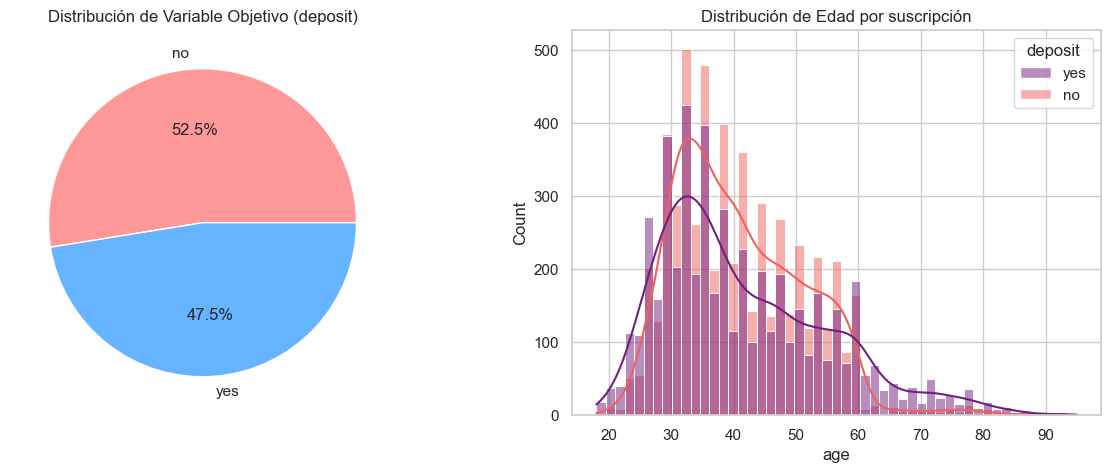


------
1. Tipo de problema: Al ser la variable objetivo 'deposit' categórica, estamos ante un problema de CLASIFICACIÓN.
2. Balanceo de clases:
deposit
no     52.55
yes    47.45
Name: proportion, dtype: float64
-> CONCLUSIÓN: El dataset está razonablemente balanceado (diferencia de solo 5.09%).


In [5]:
#visualizamos el balanceo de la variable objetivo y la relación con una variable clave
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

#gráfico 1: Balanceo
df['deposit'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', ax=ax[0], colors=['#ff9999','#66b3ff'])
ax[0].set_title('Distribución de Variable Objetivo (deposit)')

#gráfico 2: Edad vs Depósito
sns.histplot(data=df, x='age', hue='deposit', kde=True, ax=ax[1], palette='magma')
ax[1].set_title('Distribución de Edad por suscripción')

plt.show()


print("\n------")
print("1. Tipo de problema: Al ser la variable objetivo 'deposit' categórica, estamos ante un problema de CLASIFICACIÓN.")

#cálculo automático del balanceo
porcentajes = df['deposit'].value_counts(normalize=True) * 100
print(f"2. Balanceo de clases:\n{porcentajes.round(2)}")

diferencia = abs(porcentajes.iloc[0] - porcentajes.iloc[1])
if diferencia > 20:
    print(f"-> CONCLUSIÓN: El dataset presenta desbalanceo (hay una diferencia del {diferencia:.2f}% entre clases).")
else:
    print(f"-> CONCLUSIÓN: El dataset está razonablemente balanceado (diferencia de solo {diferencia:.2f}%).")

### 2.3 Análisis y preproceso de la variable `pdays`

Según el diccionario de datos, `pdays` indica los días transcurridos desde el último contacto. El valor `-1` significa que el cliente no ha sido contactado previamente.
Si dejamos el `-1`, los modelos matemáticos se confundirán. Para solucionarlo:
1. Creamos una nueva variable binaria `contactado_previamente` (1 si hubo contacto, 0 si no).
2. Reemplazamos los `-1` en la variable original `pdays` por `0`.

In [6]:
print("--- DISTRIBUCIÓN ORIGINAL DE 'pdays' ---")
print(df['pdays'].value_counts().head())

#creamos la nueva variable binaria
df['contactado_previamente'] = np.where(df['pdays'] == -1, 0, 1)

#reemplazamos el -1 por 0 en la variable original
df['pdays'] = df['pdays'].replace(-1, 0)

print("\n--- DISTRIBUCIÓN TRAS EL PREPROCESO ---")
print("Nueva variable 'contactado_previamente':")
print(df['contactado_previamente'].value_counts())

print("\nTop 5 valores actuales de 'pdays' (el -1 ha desaparecido):")
print(df['pdays'].value_counts().head())

--- DISTRIBUCIÓN ORIGINAL DE 'pdays' ---
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
Name: count, dtype: int64

--- DISTRIBUCIÓN TRAS EL PREPROCESO ---
Nueva variable 'contactado_previamente':
contactado_previamente
0    8203
1    2797
Name: count, dtype: int64

Top 5 valores actuales de 'pdays' (el -1 ha desaparecido):
pdays
0      8203
92      105
182      88
91       82
181      79
Name: count, dtype: int64


### 3. Estrategia de Evaluación

Siguiendo las instrucciones del enunciado, definimos la siguiente estrategia para asegurar la robustez de nuestros modelos:

**Evaluación Externa (Outer):** Realizaremos una partición de tipo **Holdout** reservando **1/3 de los datos para test** y **2/3 para entrenamiento**. [cite_start]El conjunto de test solo se usará al final para estimar el rendimiento futuro[cite: 46].
**Evaluación Interna (Inner):** Para la optimización de hiperparámetros (HPO) y la comparación de modelos, utilizaremos **Validación Cruzada Estratificada (Stratified K-Fold) con 5 particiones** sobre el conjunto de entrenamiento.
**Métrica de Evaluación:** Dado que el dataset está balanceado (como vimos en el EDA), usaremos la **Exactitud (Accuracy)** como métrica principal, monitorizando también el **ROC-AUC** para verificar la robustez de la clasificación[cite: 44].

In [7]:
#definimos X  e Y
X = df.drop('deposit', axis=1)

#convertimos 'yes'/'no' a 1/0 
y = df['deposit'].map({'yes': 1, 'no': 0})

#partición Hold-out (Train 2/3 y Test 1/3)
#usamos stratify=y para que el reparto sea equilibrado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=1/3,  
    random_state=RANDOM_STATE, 
    stratify=y 
)

#definimos la Validación Cruzada para el entrenamiento
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_inner = skf
scoring_metric = 'roc_auc'

print(f"✅ Estrategia de evaluación definida.")
print(f"Métrica elegida: Accuracy (Exactitud) apoyada en ROC-AUC.")
print(f"Set Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set Test: {X_test.shape[0]} muestras")

✅ Estrategia de evaluación definida.
Métrica elegida: Accuracy (Exactitud) apoyada en ROC-AUC.
Set Entrenamiento: 7333 muestras
Set Test: 3667 muestras


In [8]:
#separamos columnas por tipo
#variables numéricas estándar 
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']

#variables categóricas con nulos
cat_cols_con_nulos = ['job', 'education']

#resto
cat_cols = ['marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] 

#pdays
pdays_col = ['pdays']

#transformacion de pdays
def transform_pdays(X):
    #transform_pdays recibe un array 2D, pero nosotros queremos trabajar con un array 1D para hacer las transformaciones más fácilmente.    
   
    pdays_valores = np.array(X).flatten() #aseguramos que es un array 1D
    
    no_previo = (pdays_valores == 0).astype(int) #1 si no hay contacto previo (pdays=0), 0 si sí lo hubo
    dias_validos = pdays_valores #ya está 0 para no contactado
    return np.column_stack((no_previo, dias_validos))

def get_pdays_names(transformer, feature_names):
    return ['pdays_no_previo', 'pdays_dias_validos']

pdays_transformer = FunctionTransformer(
    transform_pdays, 
    validate=False,
    feature_names_out=get_pdays_names
)
#pipeline para las categóricas con nulos: Imputación + OneHotEncoding
cat_nulos_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#pipeline para el resto , solo el OneHotEncoding
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) #por si hubiese algun valor nulo
])


#unimos todo en ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat_nulos', cat_nulos_pipe, cat_cols_con_nulos),
        ('cat_normales', cat_pipe, cat_cols),
        ('pdays_custom', pdays_transformer, pdays_col)
    ],
    remainder='drop' 
)   

In [9]:


#convertimos la variable objetivo a números 
y_train_num = y_train
y_test_num = y_test

#usamos StandardScaler como punto de partida para el escalado
knn_default_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()) 
])

#medimos tiempo de entrenamiento directo
print("Entrenando KNN con hiperparámetros por defecto...")
inicio = time.time()
knn_default_pipe.fit(X_train, y_train_num)
final = time.time()
tiempo_default = final - inicio

#evaluamos usando la validación cruzada 
cv_scores_default = cross_val_score(knn_default_pipe, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)

print(f"Tiempo de entrenamiento (Default): {tiempo_default:.4f} segundos")
print(f"Puntuación media ({scoring_metric}) en validación interna: {cv_scores_default.mean():.4f}")

Entrenando KNN con hiperparámetros por defecto...
Tiempo de entrenamiento (Default): 0.0366 segundos
Puntuación media (roc_auc) en validación interna: 0.8189


In [10]:
#creamos el pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

#definimos la cuadricula de parametros
param_grid_knn = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]
}

#configuramos la busqueda
grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring=scoring_metric, #roc_auc
    cv=cv_inner,            
    n_jobs=-1               
)

print("Entrenando y evaluando modelos KNN... espera un momento.")
#inicimaos cronómetro
inicio = time.time()
grid_knn.fit(X_train, y_train_num)
#finalizamos cronómetro
final = time.time()
tiempo = final - inicio
print("\nEntrenamiento completado")
print(f"El tiempo de ejucción del Gridsearch es {tiempo:.4f} segundos")
print(f"Mejor combinación encontrada: {grid_knn.best_params_}")
print(f"Mejor puntuación ({scoring_metric}) en validación interna: {grid_knn.best_score_:.4f}")

Entrenando y evaluando modelos KNN... espera un momento.

Entrenamiento completado
El tiempo de ejucción del Gridsearch es 8.6850 segundos
Mejor combinación encontrada: {'knn__n_neighbors': 21, 'scaler': RobustScaler()}
Mejor puntuación (roc_auc) en validación interna: 0.8786


### 4.2 Árboles de Decisión 

A continuación, vamos a evaluar un modelo basado en Árboles de Decisión. Al igual que con KNN, primero entrenaremos un modelo con sus hiperparámetros por defecto para establecer una línea base y mediremos su tiempo de ejecución. 


In [11]:
#creamos el pipeline del árbol 
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE))])


print("Arbol por defecto")
inicio = time.time()
tree_pipeline.fit(X_train, y_train_num)
final = time.time()
tiempo = final - inicio

#evaluamos el inner del modelo por defecto
cv_scores_def_tree = cross_val_score(tree_pipeline, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)

print(f"Tiempo de entrenamiento: {tiempo:.4f} segundos")
print(f"Puntuación media ({scoring_metric}) en validación interna: {cv_scores_def_tree.mean():.4f}\n")

Arbol por defecto
Tiempo de entrenamiento: 0.2170 segundos
Puntuación media (roc_auc) en validación interna: 0.7836



#### Optimización de Hiperparámetros (HPO) para el Árbol

Para intentar mejorar el rendimiento base y evitar el sobreajuste, vamos a realizar una búsqueda en rejilla (GridSearchCV). Optimizaremos los siguientes hiperparámetros:
* max_depth:  controla la profundidad máxima del árbol.
* min_samples_split: número mínimo de muestras necesarias para dividir un nodo interno.
* criterion:  función para medir la calidad de una división.

In [12]:
# Cuadrícula de hiperparámetros
param_grid_tree = {
    'tree__max_depth': [3, 5, 7, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid_tree,
    scoring=scoring_metric, 
    cv=cv_inner,
    n_jobs=-1
)

start_time_hpo = time.time()
grid_tree.fit(X_train, y_train_num)
end_time_hpo = time.time()
tiempo_hpo_tree = end_time_hpo - start_time_hpo

print("¡Entrenamiento completado!")
print(f"Tiempo de ejecución del GridSearch: {tiempo_hpo_tree:.4f} segundos")
print(f"Mejor combinación: {grid_tree.best_params_}")
print(f"Mejor puntuación ({scoring_metric}) en validación interna: {grid_tree.best_score_:.4f}")

¡Entrenamiento completado!
Tiempo de ejecución del GridSearch: 4.3948 segundos
Mejor combinación: {'tree__criterion': 'entropy', 'tree__max_depth': 10, 'tree__min_samples_split': 20}
Mejor puntuación (roc_auc) en validación interna: 0.8834


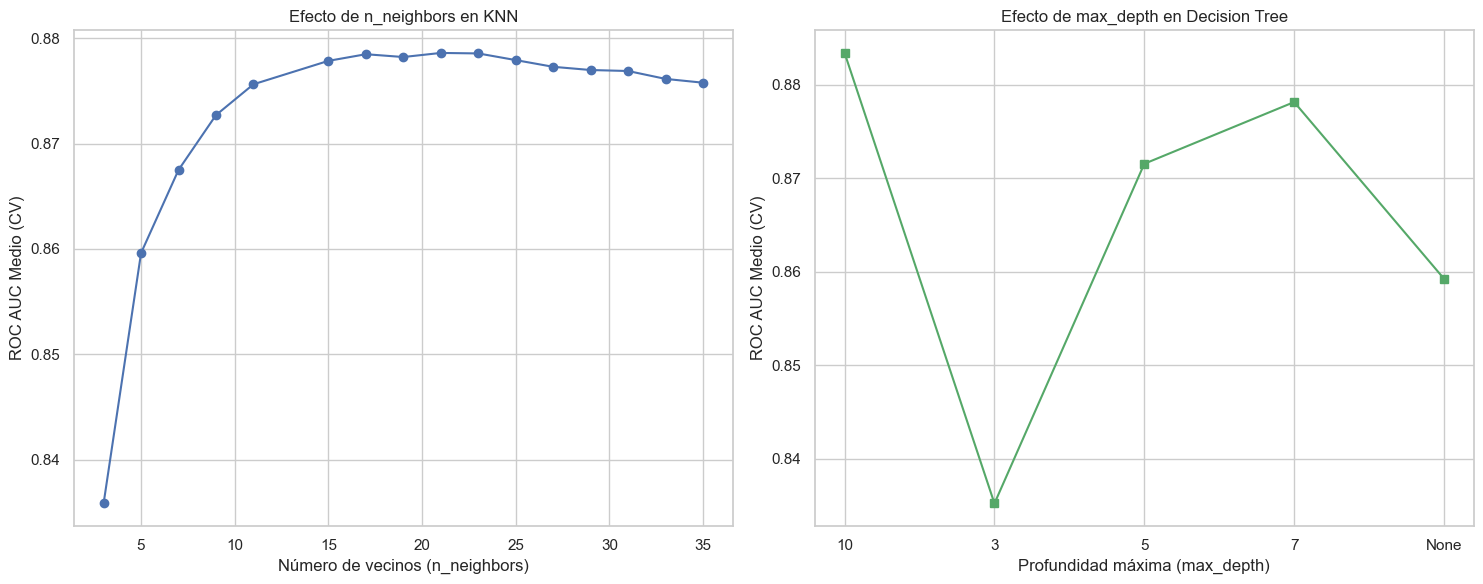

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#gráfica para KNN: Efecto de n_neighbors
knn_res = pd.DataFrame(grid_knn.cv_results_)

#agrupamos por el número de vecinos y sacamos el mejor score para cada uno
knn_plot_data = knn_res.groupby('param_knn__n_neighbors')['mean_test_score'].max().reset_index()

axes[0].plot(knn_plot_data['param_knn__n_neighbors'], knn_plot_data['mean_test_score'], marker='o', color='b')
axes[0].set_title('Efecto de n_neighbors en KNN')
axes[0].set_xlabel('Número de vecinos (n_neighbors)')
axes[0].set_ylabel('ROC AUC Medio (CV)')
axes[0].grid(True)

#gráfica para Decision Tree: Efecto de max_depth
tree_res = pd.DataFrame(grid_tree.cv_results_)

#como max_depth puede tener valores 'None' (sin límite), lo pasamos a texto
tree_res['param_tree__max_depth'] = tree_res['param_tree__max_depth'].fillna('None').astype(str)

#agrupamos por profundidad y sacamos el mejor score para cada una
tree_plot_data = tree_res.groupby('param_tree__max_depth')['mean_test_score'].max().reset_index()

axes[1].plot(tree_plot_data['param_tree__max_depth'], tree_plot_data['mean_test_score'], marker='s', color='g')
axes[1].set_title('Efecto de max_depth en Decision Tree')
axes[1].set_xlabel('Profundidad máxima (max_depth)')
axes[1].set_ylabel('ROC AUC Medio (CV)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Interpretabilidad y Extracción de Conocimiento 

Una de las grandes ventajas de los árboles de decisión frente a métodos como KNN es que son modelos de "caja blanca". Para extraer conocimiento de negocio y entender qué variables son las más determinantes para que un cliente suscriba un depósito, vamos a entrenar un árbol poco profundo (*shallow tree* con max_depth=3) y lo visualizaremos.

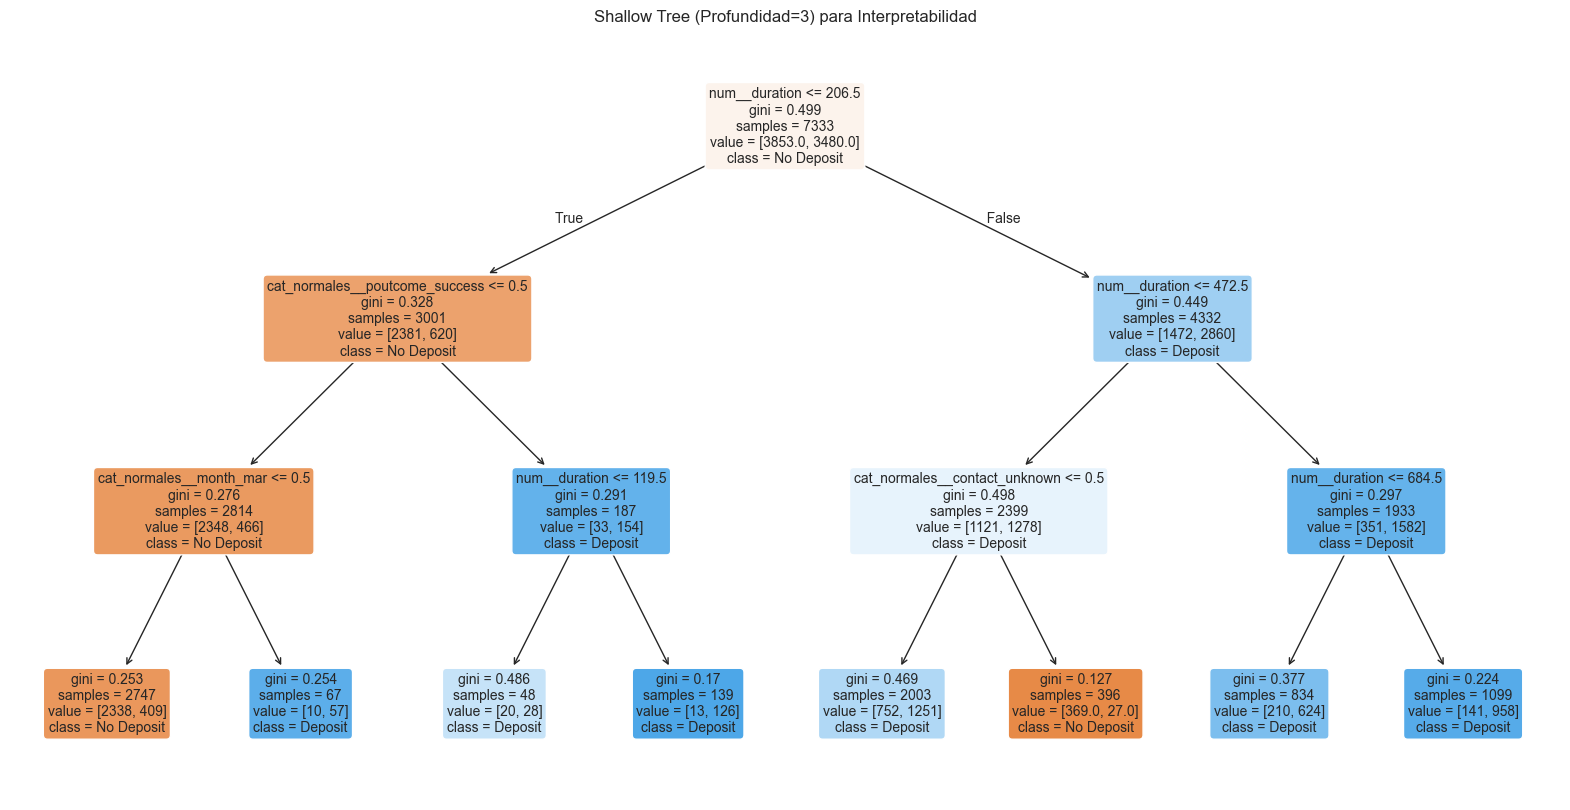

In [14]:
#entrenamos un árbol de profundidad 3 como ejemplo
shallow_tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
])
shallow_tree_pipe.fit(X_train, y_train_num)

#extraemos el modelo y los nombres de las columnas
modelo_arbol = shallow_tree_pipe.named_steps['tree']
nombres_features = shallow_tree_pipe.named_steps['preprocessor'].get_feature_names_out()

#dibujamos el árbol
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol, feature_names=nombres_features, 
          class_names=['No Deposit', 'Deposit'], filled=True, 
          rounded=True, fontsize=10)
plt.title("Shallow Tree (Profundidad=3) para Interpretabilidad")
plt.show()

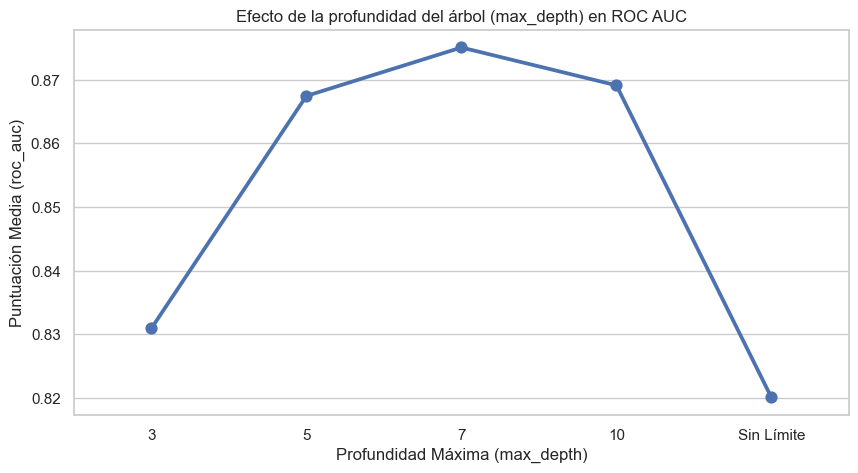

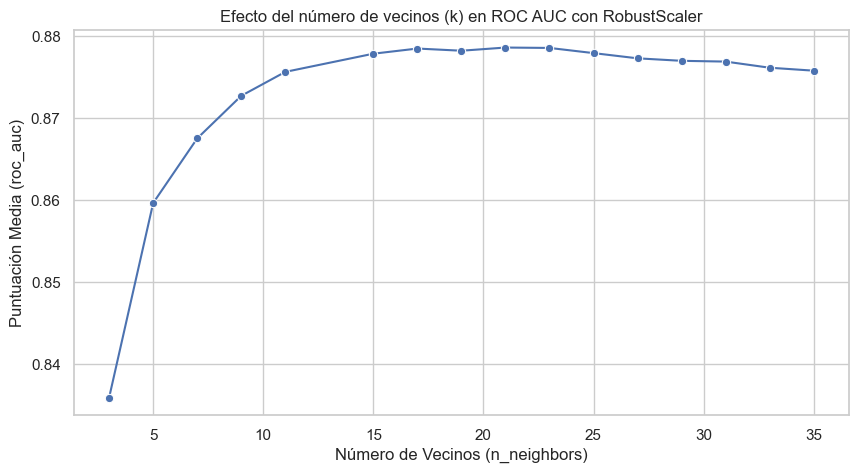

In [15]:
import seaborn as sns


resultados_tree = pd.DataFrame(grid_tree.cv_results_)
#convertimos todo explícitamente a texto (string) para que no haya problemas
resultados_tree['param_tree__max_depth'] = resultados_tree['param_tree__max_depth'].fillna('Sin Límite').astype(str)

plt.figure(figsize=(10, 5))
#cambiamos lineplot por pointplot, que gestiona perfecto el texto y los números en el eje X
sns.pointplot(data=resultados_tree, x='param_tree__max_depth', y='mean_test_score', errorbar=None)
plt.title("Efecto de la profundidad del árbol (max_depth) en ROC AUC")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel(f"Puntuación Media ({scoring_metric})")
plt.grid(True, axis='y')
plt.show()


resultados_knn = pd.DataFrame(grid_knn.cv_results_)
mejor_escalador_str = grid_knn.best_params_['scaler'].__class__.__name__
resultados_knn_filtrados = resultados_knn[resultados_knn['param_scaler'].astype(str).str.contains(mejor_escalador_str)]

plt.figure(figsize=(10, 5))

sns.lineplot(data=resultados_knn_filtrados, x='param_knn__n_neighbors', y='mean_test_score', marker='o')
plt.title(f"Efecto del número de vecinos (k) en ROC AUC con {mejor_escalador_str}")
plt.xlabel("Número de Vecinos (n_neighbors)")
plt.ylabel(f"Puntuación Media ({scoring_metric})")
plt.grid(True)
plt.show()

#### Conclusiones de los resultados (KNN vs Árboles)

Tras la optimización de hiperparámetros, observamos varios comportamientos clave en las gráficas de validación cruzada:
* En los Árboles de Decisión: Observamos claramente la tendencia al sobreajuste (overfitting). A medida que aumentamos la profundidad permitida del árbol, el rendimiento en test (CV) se estanca y puede llegar a caer. El GridSearchCV ha determinado de manera automática que el punto óptimo se encuentra podando el árbol a una profundidad de max_depth=7.

* En el algoritmo KNN: Vemos una fuerte dependencia del escalador utilizado (resultando ganador RobustScaler, ya que maneja mejor los valores atípicos de nuestro dataset, como la variable balance). El número óptimo de vecinos sube hasta K=25, creando fronteras de decisión mucho más suaves y generalizables.

Ambos modelos básicos logran resultados muy similares de ROC-AUC (~0.879). Sin embargo, el Árbol de Decisión cuenta con la ventaja de ser explicable y tener un tiempo de predicción mucho más rápido.

In [16]:
from sklearn.linear_model import LogisticRegression

# 1. Creamos el Pipeline para Regresión Logística
# Es vital incluir el escalado aquí
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# 2. Evaluación por defecto (Baseline)
print("--- Regresión Logística: Parámetros por defecto ---")
inicio = time.time()
logreg_pipe.fit(X_train, y_train_num)
tiempo_lr_def = time.time() - inicio

cv_scores_lr_def = cross_val_score(logreg_pipe, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric)

print(f"Tiempo entrenamiento: {tiempo_lr_def:.4f}s")
print(f"Puntuación media ({scoring_metric}): {cv_scores_lr_def.mean():.4f}\n")

# 3. Optimización (HPO) - Probamos penalizaciones L1 (Lasso) y L2 (Ridge)
param_grid_lr = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100], # Inverso de la fuerza de regularización
    'clf__solver': ['liblinear']      # 'liblinear' funciona bien con l1 y l2
}

grid_lr = GridSearchCV(logreg_pipe, param_grid_lr, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
grid_lr.fit(X_train, y_train_num)

print(f"Mejor puntuación HPO: {grid_lr.best_score_:.4f}")
print(f"Mejores parámetros: {grid_lr.best_params_}")

--- Regresión Logística: Parámetros por defecto ---
Tiempo entrenamiento: 0.1598s
Puntuación media (roc_auc): 0.9047

Mejor puntuación HPO: 0.9050
Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time


#regresión Logística 
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])


logreg_l1_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg_l1', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))
])

#support Vector Machine (SVM)
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('svm', SVC(random_state=RANDOM_STATE))
])


def evaluar_modelo_avanzado(pipeline, nombre):
    print(f"Entrenando {nombre}...")
    inicio = time.time()
    pipeline.fit(X_train, y_train_num)
    tiempo_fit = time.time() - inicio
    
    #validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
    
    print(f"--> Tiempo: {tiempo_fit:.4f}s | Puntuación Media ({scoring_metric}): {cv_scores.mean():.4f}\n")


print("EVALUACIÓN POR DEFECTO MÉTODOS AVANZADOS\n")
evaluar_modelo_avanzado(logreg_pipe, "Regresión Logística (Default/L2)")
evaluar_modelo_avanzado(logreg_l1_pipe, "Regresión Logística (L1)")
evaluar_modelo_avanzado(svm_pipe, "Support Vector Machine (SVM)")

EVALUACIÓN POR DEFECTO MÉTODOS AVANZADOS

Entrenando Regresión Logística (Default/L2)...
--> Tiempo: 0.4542s | Puntuación Media (roc_auc): 0.9041

Entrenando Regresión Logística (L1)...
--> Tiempo: 0.2232s | Puntuación Media (roc_auc): 0.9046

Entrenando Support Vector Machine (SVM)...
--> Tiempo: 4.3393s | Puntuación Media (roc_auc): 0.8921



In [18]:
import warnings
warnings.filterwarnings('ignore') 
#optimizamos el parámetro 'C' 
param_grid_logreg = {
    'logreg__C': [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid_logreg,
    scoring=scoring_metric,
    cv=cv_inner,
    n_jobs=-1
)

print("Iniciando GridSearch para Regresión Logística...")
inicio = time.time()
grid_logreg.fit(X_train, y_train_num)
tiempo_logreg_hpo = time.time() - inicio

print(f"Mejor LogReg (C={grid_logreg.best_params_['logreg__C']}) -> ROC AUC: {grid_logreg.best_score_:.4f} (Tiempo: {tiempo_logreg_hpo:.4f}s)\n")


#el SVM es lento, así que probamos una cuadrícula pequeñita para no eternizarnos
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    scoring=scoring_metric,
    cv=cv_inner,
    n_jobs=-1
)

print("Iniciando GridSearch para SVM")
inicio = time.time()
grid_svm.fit(X_train, y_train_num)
tiempo_svm_hpo = time.time() - inicio

print(f"Mejor SVM ({grid_svm.best_params_}) -> ROC AUC: {grid_svm.best_score_:.4f} (Tiempo: {tiempo_svm_hpo:.4f}s)")

Iniciando GridSearch para Regresión Logística...
Mejor LogReg (C=100) -> ROC AUC: 0.9047 (Tiempo: 2.8832s)

Iniciando GridSearch para SVM
Mejor SVM ({'svm__C': 10, 'svm__kernel': 'linear'}) -> ROC AUC: 0.9046 (Tiempo: 98.4069s)


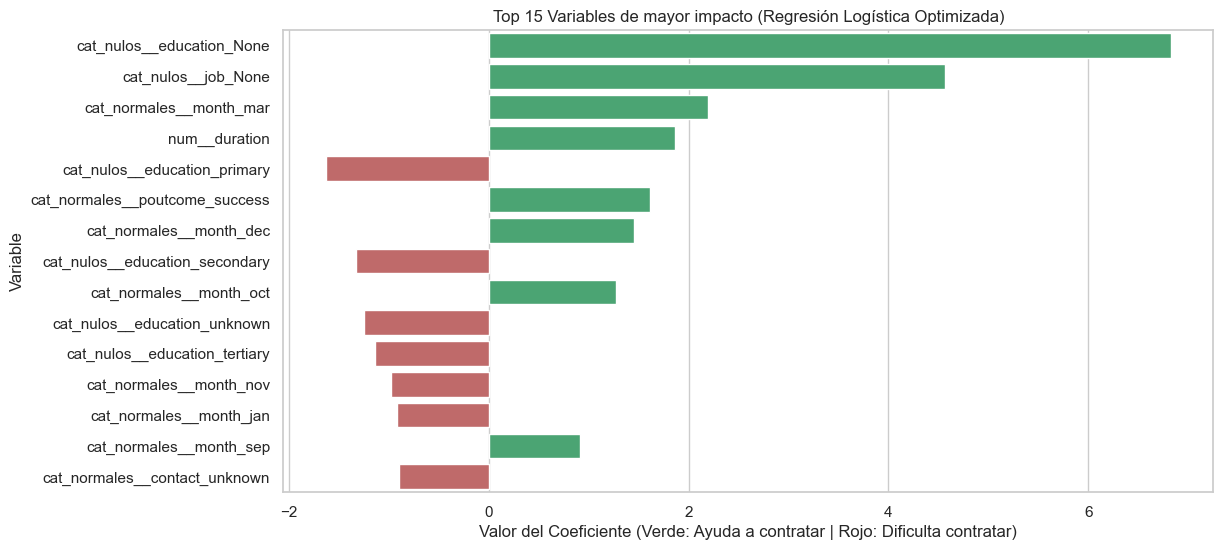

In [19]:
#extraemos el mejor modelo de Regresión Logística para analizar la importancia de variables
mejor_logreg_pipe = grid_logreg.best_estimator_
modelo_logreg = mejor_logreg_pipe.named_steps['logreg']
preprocesador_logreg = mejor_logreg_pipe.named_steps['preprocessor']

# 2. Obtenemos los nombres de las variables transformadas y sus coeficientes
nombres_variables = preprocesador_logreg.get_feature_names_out()
coeficientes = modelo_logreg.coef_[0]

#creamos un DataFrame para ordenar la información
importancia_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes) 
})

#ordenamos de mayor a menor impacto
importancia_df = importancia_df.sort_values(by='Importancia_Absoluta', ascending=False)
top_15_variables = importancia_df.head(15)

# 4. Visualizamos
plt.figure(figsize=(12, 6))
#pintamos de verde si el coeficiente es positivo y rojo si es negativo
sns.barplot(
    data=top_15_variables, 
    x='Coeficiente', 
    y='Variable', 
    hue=top_15_variables['Coeficiente'] > 0, 
    palette={True: 'mediumseagreen', False: 'indianred'}, 
    legend=False
)
plt.title("Top 15 Variables de mayor impacto (Regresión Logística Optimizada)")
plt.xlabel("Valor del Coeficiente (Verde: Ayuda a contratar | Rojo: Dificulta contratar)")
plt.ylabel("Variable")
plt.grid(True, axis='x')
plt.show()

RESULTADOS Y MODELO FINAL

Mejor modelo seleccionado: logreg
Mejor métrica (Inner): 0.9047
ESTIMACIÓN DEL RENDIMIENTO FUTURO (TEST)
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1927
           1       0.84      0.79      0.82      1740

    accuracy                           0.83      3667
   macro avg       0.83      0.83      0.83      3667
weighted avg       0.83      0.83      0.83      3667

ROC-AUC en Test: 0.9169


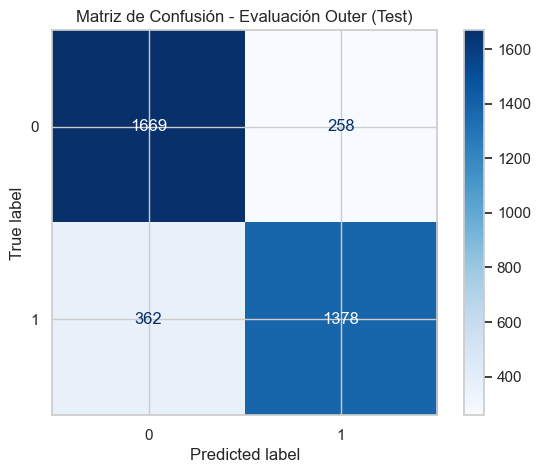


Modelo final entrenado 
Predicciones para 'bank_competition.pkl' generadas con éxito en 'predicciones.csv'


In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score


#selección de la mejor alternativa (Evaluación Inner)

mejor_modelo_grid = grid_logreg

mejor_pipeline = mejor_modelo_grid.best_estimator_
print(f"Mejor modelo seleccionado: {mejor_pipeline.steps[-1][0]}")
print(f"Mejor métrica (Inner): {mejor_modelo_grid.best_score_:.4f}")


#evaluación Outer 

y_pred_test = mejor_pipeline.predict(X_test)
y_probs_test = mejor_pipeline.predict_proba(X_test)[:, 1] if hasattr(mejor_pipeline, "predict_proba") else None


print("ESTIMACIÓN DEL RENDIMIENTO FUTURO (TEST)")

print(classification_report(y_test, y_pred_test))

if y_probs_test is not None:
    print(f"ROC-AUC en Test: {roc_auc_score(y_test, y_probs_test):.4f}")

#representación de la Matriz de Confusión 
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mejor_pipeline.classes_)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matriz de Confusión - Evaluación Outer (Test)")
plt.show()


#entrenamiento del modelo final y guardado
 
import pickle
with open('modelo_final.pkl', 'wb') as f:
    pickle.dump(mejor_pipeline, f)
print("\nModelo final guardado correctamente como 'modelo_final.pkl'")

#predicciones para el conjunto de datos de la competición

 
archivo_competicion = 'bank_competition.pkl'

try:
    df_competicion = pd.read_pickle(archivo_competicion)
    
    # Aplicar el mismo preproceso que al dataset de entrenamiento
    df_competicion['contactado_previamente'] = np.where(df_competicion['pdays'] == -1, 0, 1)
    df_competicion['pdays'] = df_competicion['pdays'].replace(-1, 0)
    
    #realizamos las predicciones 
    predicciones_finales = mejor_pipeline.predict(df_competicion)
    
    #guardamos en 'predicciones.csv' 
    df_output = pd.DataFrame(predicciones_finales, columns=['deposit'])
    df_output.to_csv('predicciones.csv', index=False)
    
    print(f"Predicciones para '{archivo_competicion}' generadas con éxito en 'predicciones.csv'")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_competicion}'.")